# 06 · Evaluation metrics and statistical inference (protocol §6–7.4)

This notebook covers how performance is measured, how the primary comparison is tested, and how the result is interpreted under the prespecified decision rule.

## 1. Metrics at a threshold: the confusion matrix
Once a threshold turns each score into a predicted label:

| | predicted patient | predicted control |
|---|---|---|
| **actual patient** | true positive (TP) | false negative (FN) |
| **actual control** | false positive (FP) | true negative (TN) |

The metrics built from it:
- **Sensitivity** (true-positive rate, recall) $= TP/(TP+FN)$: the share of patients who are detected.
- **Specificity** (true-negative rate) $= TN/(TN+FP)$: the share of controls who are correctly cleared.
- **Positive predictive value (PPV, precision)** $= TP/(TP+FP)$: the share of positive calls that are really patients. It **depends on prevalence**.
- **Balanced accuracy** $= (\text{sensitivity} + \text{specificity})/2$. Plain accuracy can look good by always predicting the majority class; balanced accuracy cannot.

## 2. Threshold-free metrics
**ROC curve and ROC-AUC.**
- The ROC curve plots sensitivity against 1 − specificity for every possible threshold.
- **AUC** is the area under that curve. It equals the probability that a randomly chosen patient gets a higher score than a randomly chosen control, so it measures **ranking discrimination** (0.5 = chance, 1 = perfect).
- AUC is relatively **insensitive to class prevalence**. That is useful for comparing models, but it also means a good AUC says nothing about PPV. In a population where patients are rare, a model with a good AUC can still produce mostly false alarms (Demo 2).

**PR curve and PR-AUC (average precision).**
- The PR curve plots precision (PPV) against recall (sensitivity).
- Its chance level equals the **prevalence**, not 0.5, so PR-AUC is always reported next to the prevalence of the test fold.
- It is more sensitive to imbalance, and more relevant when positive calls matter.

**Why report several metrics.** No single number describes a classifier. AUC describes ranking, PR-AUC describes precision, and the threshold-based metrics describe what happens at the operating point.

## 3. Compute per fold, then average
- Every outer fold has its own fitted model, and SVM scores from different models are on **different scales**.
- Pooling all 50 folds' scores into one ROC would mix those scales and understate discrimination (Demo 4).
- Each metric is therefore computed **within each outer test fold** and then averaged across folds.
- The SD across folds describes how much performance varies with the partition. It is **not** a standard error.

## 4. The primary comparison: paired ΔAUC and its uncertainty
For each of the $J = 50$ outer folds, $d_j = \mathrm{AUC}^{(j)}_{\mathrm{MKL}} - \mathrm{AUC}^{(j)}_{\mathrm{functional}}$ is computed on the same test participants. The estimate is the mean $\bar d$.

**Why the naive standard error is wrong.**
- The textbook SE is $s_d/\sqrt J$, but the 50 differences are **not independent**.
- Training sets overlap heavily: any two folds share about 75% of their training participants.
- Every participant is reused in every repeat.
- The naive interval is therefore far too narrow.

**Nadeau–Bengio corrected resampled t** (2003) inflates the variance to account for the overlap:

$$\widehat{\mathrm{SE}} = \sqrt{\Big(\frac1J + \frac{n_{\text{test}}}{n_{\text{train}}}\Big)\, s_d^2},\qquad \frac{n_{\text{test}}}{n_{\text{train}}} = \frac14 \text{ for 5-fold CV},$$

with a $t$ distribution on $J-1$ degrees of freedom. The correction is approximate, so the interval is read *together with* the permutation test, never alone.

## 5. Permutation testing
**Null hypothesis.** A statement of "no effect", for example "the labels are unrelated to the imaging data".

**Exchangeability.** Under the null, shuffling the labels across participants gives data that are just as plausible as the real data.

**The procedure:**
1. shuffle (permute) the labels;
2. rerun the **complete** nested pipeline: splits, standardization, kernel normalization, C/β selection, threshold and evaluation;
3. record the statistic;
4. repeat $B = 1000$ times.

The $B$ values form the **null distribution**. The Monte Carlo p-value is the share of null values at least as extreme as the observed one, computed with the **plus-one correction**:

$$p = \frac{1 + \#\{\text{null} \ge \text{observed}\}}{1 + B}.$$

The "+1" counts the observed data as one of the permutations. This keeps the test valid and means $p$ can never be exactly 0; the smallest possible value is $1/1001$.

**Why the complete pipeline is rerun.** Tuning is part of the method. A null built without retuning C and β would be narrower than the real procedure's variability and would give p-values that are too small.

**What a permutation test does *not* establish:** causal validity, clinical utility, or generalization to other sites. It only shows that the result would be unusual *within this dataset* if the null were true.

### Which null for which question
| Question | Null | How it is generated |
|---|---|---|
| Does each model beat chance? | labels are unrelated to the imaging data | permute the **labels** |
| **Primary:** does MKL beat the functional model? | structural features carry no information MKL can use | permute the **rows of $X_s$** across participants, keeping labels, $X_f$ and confounds fixed |

**Why label permutation cannot test ΔAUC.** Shuffling labels destroys the signal in *both* modalities, so both models fall to chance and ΔAUC centres on 0 whether or not structural MRI adds anything. That null answers "do the models differ when there is no signal at all?", which is the wrong question. Permuting only the structural block keeps the functional signal intact and removes only what structural MRI could add.

**Caveat.** Block permutation also breaks any dependence between $X_s$ and $X_f$. It therefore tests "is $X_s$ usable at all?", not strict conditional independence.

## 6. Multiple comparisons
Each extra test at α = 0.05 adds another 5% chance of a false positive. The **family-wise error rate** is the chance of at least one false positive among several tests, and it grows with the number of tests.

The four secondary comparisons (MKL vs early fusion, equal weight, stacking and structural) are corrected with **Holm's step-down procedure**:
1. sort the $m$ p-values from smallest to largest;
2. multiply the $k$-th smallest by $(m - k + 1)$;
3. enforce monotonicity, so an adjusted p-value is never smaller than the one before it.

Holm controls the family-wise error rate and is uniformly more powerful than Bonferroni. Every other comparison is labelled **exploratory**.

## 7. The prespecified decision rule
$\delta = 0.02$ is the **minimum meaningful difference** in AUC.

| Result | Criteria |
|---|---|
| **Superiority supported** | $p_{\text{block}} < 0.05$ **and** CI lower bound > 0 **and** $\bar d \ge \delta$ |
| **Detectable but small** | $p_{\text{block}} < 0.05$ and CI lower bound > 0, but $\bar d < \delta$ |
| **No meaningful incremental value** | CI upper bound < δ: a meaningful gain is ruled out |
| **Inconclusive** | none of the above |

**Null interpretation.** Failure of MKL to beat the functional model is not a failed experiment. It is evidence that fusion gave no detectable incremental value under this dataset and validation design.

In [1]:
from pathlib import Path
from functools import partial
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from joblib import Parallel, delayed
from scipy import stats
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"
RESULTS = ROOT / "results"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
use_notebook("05_nested_cross_validation.ipynb")   # splits, run_nested_cv, load_design (+ notebook 04)

In [3]:
FOLD_KEYS = ["model", "repeat", "fold"]
METRICS = ["auc", "pr_auc", "balanced_accuracy", "sensitivity", "specificity"]


def fold_metrics(predictions, zero_threshold=False):
    """One row per (model, repeat, fold) with every protocol §6 metric."""
    rows = []
    for (model, repeat, fold), g in predictions.groupby(FOLD_KEYS, sort=False):
        y = g["y_true"].to_numpy(int)
        score = g["score"].to_numpy(float)
        y_pred = (score >= 0).astype(int) if zero_threshold else g["y_pred"].to_numpy(int)
        sensitivity = float(np.mean(y_pred[y == 1] == 1))
        specificity = float(np.mean(y_pred[y == 0] == 0))
        rows.append({"model": model, "repeat": repeat, "fold": fold, "n_test": len(y),
                     "prevalence": float(y.mean()), "auc": roc_auc_score(y, score),
                     "pr_auc": average_precision_score(y, score),
                     "balanced_accuracy": (sensitivity + specificity) / 2,
                     "sensitivity": sensitivity, "specificity": specificity})
    return pd.DataFrame(rows)


def summarize(folds):
    """Mean and SD across outer folds (the SD describes partition variability, not an SE)."""
    summary = folds.groupby("model", sort=False)[METRICS + ["prevalence"]].agg(["mean", "std"])
    summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
    return summary.reset_index()


def fold_auc(predictions):
    """Outer-fold AUC indexed by (model, repeat, fold); the fast path used by permutations."""
    return pd.Series({key: roc_auc_score(g["y_true"], g["score"])
                      for key, g in predictions.groupby(FOLD_KEYS, sort=False)}, name="auc")


def mean_auc_by_model(predictions):
    return fold_auc(predictions).groupby(level=0).mean()


def _paired(a, b):
    if a.empty or b.empty or set(a.index) != set(b.index):
        raise ValueError("Paired comparison requires both models on identical outer folds.")
    return (a - b.reindex(a.index)).to_numpy(float)


def paired_differences(folds, model_a, model_b, metric="auc"):
    """Fold-level metric(model_a) - metric(model_b) on identical test participants."""
    def per_model(name):
        return folds[folds["model"] == name].set_index(["repeat", "fold"])[metric]
    return _paired(per_model(model_a), per_model(model_b))


def mean_paired_auc_difference(predictions, model_a, model_b):
    auc = fold_auc(predictions)
    return float(np.mean(_paired(auc.xs(model_a, level=0), auc.xs(model_b, level=0))))


def corrected_resampled_ci(diffs, test_train_ratio, alpha=0.05):
    """Nadeau & Bengio (2003) corrected repeated-CV interval for a mean paired difference."""
    d = np.asarray(diffs, dtype=float)
    J = len(d)
    mean = float(d.mean())
    se = float(np.sqrt((1.0 / J + test_train_ratio) * d.var(ddof=1)))
    t_crit = stats.t.ppf(1 - alpha / 2, J - 1)
    p = float(2 * stats.t.sf(abs(mean) / se, J - 1)) if se > 0 else (0.0 if mean != 0 else 1.0)
    return {"mean": mean, "se": se, "ci_low": mean - t_crit * se, "ci_high": mean + t_crit * se,
            "p_two_sided": p, "n_folds": J}


def permutation_p_value(observed, null, alternative="greater"):
    """Monte Carlo p-value with the plus-one correction: (1 + #extreme) / (1 + B)."""
    null = np.asarray(null, dtype=float)
    if alternative == "greater":
        extreme = np.sum(null >= observed)
    elif alternative == "two-sided":
        extreme = np.sum(np.abs(null) >= abs(observed))
    else:
        raise ValueError(f"Unknown alternative {alternative!r}")
    return float((1 + extreme) / (1 + len(null)))


def holm(pvalues):
    """Holm step-down adjusted p-values for a {name: p} mapping."""
    names = sorted(pvalues, key=pvalues.get)
    m = len(names)
    adjusted, running = {}, 0.0
    for rank, name in enumerate(names):
        running = max(running, min(1.0, (m - rank) * pvalues[name]))
        adjusted[name] = running
    return adjusted


def classify_primary_result(mean, ci_low, ci_high, p_perm, delta, alpha=0.05):
    """Prespecified decision rule of protocol §7.3."""
    if p_perm < alpha and ci_low > 0 and mean >= delta:
        return "superiority supported"
    if p_perm < alpha and ci_low > 0:
        return "detectable but below the minimum meaningful difference"
    if ci_high < delta:
        return "no meaningful incremental value"
    return "inconclusive"

In [4]:
def permuted_dataset(X, y, kind, index, seed, block=None):
    """Permutation ``index`` of the data, from its own reproducible RNG stream.

    kind="labels": permute diagnosis labels (null: no label-imaging association).
    kind="block":  permute the rows of one feature block, keeping labels and other blocks fixed.
    """
    perm = np.random.default_rng([seed, index]).permutation(len(y))
    if kind == "labels":
        return X, y[perm]
    if kind == "block":
        X_perm = X.copy()
        X_perm[:, block] = X[np.ix_(perm, block)]
        return X_perm, y
    raise ValueError(f"Unknown permutation kind {kind!r}")


def run_permutations(X, y, ids, model_factory, seeds, statistic, kind, indices, seed,
                     block=None, n_outer=5, n_inner=5, n_jobs=1):
    """Null distribution of ``statistic(predictions)``, rerunning the full nested pipeline each time."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)

    def one(index):
        X_perm, y_perm = permuted_dataset(X, y, kind, index, seed, block)
        predictions, _, _ = run_nested_cv(X_perm, y_perm, ids, model_factory, seeds, n_outer, n_inner)
        return statistic(predictions)

    indices = list(indices)
    values = Parallel(n_jobs=n_jobs)(delayed(one)(i) for i in indices)
    rows = [{"permutation": i, **(v.to_dict() if isinstance(v, pd.Series) else {"statistic": float(v)})}
            for i, v in zip(indices, values)]
    return pd.DataFrame(rows)


def run_permutation_chunk(kind, start=0, n_permutations=None, functional_strategy="primary",
                          strict_patients=False, tag="", n_jobs=-1):
    """One resumable chunk of the real-data null: kind = "structural_block" or "labels"."""
    model_cfg = load_yaml(ROOT / "configs" / "model_config.yaml")
    cv_cfg = load_yaml(ROOT / "configs" / "cv_config.yaml")
    data_cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
    seeds = read_seeds(ROOT / cv_cfg["seeds_file"])
    X, y, ids, blocks, _ = load_design(data_cfg, functional_strategy, strict_patients)
    perm_cfg = cv_cfg["permutation"]
    indices = range(start, start + (n_permutations or perm_cfg["n_permutations"]))
    common = dict(n_outer=cv_cfg["outer"]["n_splits"], n_inner=cv_cfg["inner"]["n_splits"], n_jobs=n_jobs)
    if kind == "structural_block":
        a, b = model_cfg["primary_comparison"]["model"], model_cfg["primary_comparison"]["comparator"]
        null = run_permutations(X, y, ids, partial(build_models, model_cfg, blocks, include=[a, b]), seeds,
                                partial(mean_paired_auc_difference, model_a=a, model_b=b), "block",
                                indices, perm_cfg["seed"], block=blocks["structural"], **common)
    elif kind == "labels":
        names = [m["name"] for m in model_cfg["models"] if m["role"] != "sensitivity"]
        null = run_permutations(X, y, ids, partial(build_models, model_cfg, blocks, include=names), seeds,
                                mean_auc_by_model, "labels", indices, perm_cfg["seed"], **common)
    else:
        raise ValueError(f"Unknown null {kind!r}")
    out_dir = RESULTS / "permutation_tests" / f"{kind}{'_' + tag if tag else ''}"
    out_dir.mkdir(parents=True, exist_ok=True)
    null.to_csv(out_dir / f"chunk_{indices.start:04d}-{indices.stop - 1:04d}.csv", index=False)
    return null


def load_null(name, suffix=""):
    """Concatenate saved permutation chunks; None if there are none yet."""
    chunks = sorted((RESULTS / "permutation_tests" / f"{name}{suffix}").glob("chunk_*.csv"))
    if not chunks:
        return None
    null = pd.concat([pd.read_csv(c) for c in chunks], ignore_index=True)
    if null["permutation"].duplicated().any():
        raise ValueError(f"Duplicate permutation indices in {name}{suffix} chunks.")
    return null


def report_results(tag=""):
    """Metrics, paired comparisons, the primary decision and beats-chance tests from saved results."""
    model_cfg = load_yaml(ROOT / "configs" / "model_config.yaml")
    cv_cfg = load_yaml(ROOT / "configs" / "cv_config.yaml")
    alpha = cv_cfg["inference"]["alpha"]
    delta = cv_cfg["inference"]["min_meaningful_delta_auc"]
    ratio = 1.0 / (cv_cfg["outer"]["n_splits"] - 1)
    suffix = f"_{tag}" if tag else ""
    out = RESULTS / "metrics"
    out.mkdir(parents=True, exist_ok=True)

    predictions = pd.read_csv(RESULTS / "predictions" / f"predictions{suffix}.csv")
    folds = fold_metrics(predictions)
    folds.to_csv(out / f"fold_metrics{suffix}.csv", index=False)
    summary = summarize(folds)
    summary.to_csv(out / f"summary{suffix}.csv", index=False)
    summarize(fold_metrics(predictions, zero_threshold=True)).to_csv(out / f"summary_threshold0{suffix}.csv", index=False)

    present = set(predictions["model"])
    a, b = model_cfg["primary_comparison"]["model"], model_cfg["primary_comparison"]["comparator"]
    pairs = [("primary", a, b)] + [("secondary", x, z) for x, z in model_cfg["secondary_comparisons"]]
    comparisons = pd.DataFrame([{"role": role, "model": x, "comparator": z,
                                 **corrected_resampled_ci(paired_differences(folds, x, z), ratio, alpha)}
                                for role, x, z in pairs if {x, z} <= present])
    secondary = comparisons[comparisons["role"] == "secondary"]
    adjusted = holm(dict(zip(secondary["comparator"], secondary["p_two_sided"])))
    comparisons["p_holm"] = [adjusted.get(z) if r == "secondary" else None
                             for r, z in zip(comparisons["role"], comparisons["comparator"])]
    comparisons.to_csv(out / f"comparisons{suffix}.csv", index=False)

    primary = comparisons[comparisons["role"] == "primary"].iloc[0]
    result = {"comparison": f"{a} - {b}", "mean_delta_auc": primary["mean"], "ci_low": primary["ci_low"],
              "ci_high": primary["ci_high"], "delta": delta, "alpha": alpha}
    block_null = load_null("structural_block", suffix)
    if block_null is None:
        result["result"] = "pending: run the structural-block permutations"
    else:
        result["n_permutations"] = len(block_null)
        result["p_block_permutation"] = permutation_p_value(primary["mean"], block_null["statistic"])
        result["result"] = classify_primary_result(primary["mean"], primary["ci_low"], primary["ci_high"],
                                                   result["p_block_permutation"], delta, alpha)
    (out / f"primary_result{suffix}.json").write_text(json.dumps(result, indent=2, default=float))

    beats_chance = None
    label_null = load_null("labels", suffix)
    if label_null is not None:
        observed = mean_auc_by_model(predictions)
        beats_chance = pd.DataFrame([{"model": m, "mean_auc": observed[m], "n_permutations": len(label_null),
                                      "p_permutation": permutation_p_value(observed[m], label_null[m])}
                                     for m in observed.index if m in label_null.columns])
        beats_chance.to_csv(out / f"beats_chance{suffix}.csv", index=False)
    return {"summary": summary, "comparisons": comparisons, "primary": result, "beats_chance": beats_chance}

## Demo 1: the confusion matrix and threshold metrics
Ten toy participants, classified at threshold 0.

In [5]:
y_toy = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0])
score_toy = np.array([2.1, 0.8, 0.3, -0.4, 0.6, -0.2, -0.5, -1.0, -1.3, -2.0])
pred_toy = (score_toy >= 0).astype(int)
tp, fn = int(((pred_toy == 1) & (y_toy == 1)).sum()), int(((pred_toy == 0) & (y_toy == 1)).sum())
fp, tn = int(((pred_toy == 1) & (y_toy == 0)).sum()), int(((pred_toy == 0) & (y_toy == 0)).sum())
display(pd.DataFrame([[tp, fn], [fp, tn]], index=["actual patient", "actual control"],
                     columns=["predicted patient", "predicted control"]))
sens, spec = tp / (tp + fn), tn / (tn + fp)
print(f"sensitivity {sens:.2f} | specificity {spec:.2f} | PPV {tp / (tp + fp):.2f} | "
      f"balanced accuracy {(sens + spec) / 2:.2f} | ROC-AUC {roc_auc_score(y_toy, score_toy):.2f}")

,predicted patient,predicted control
actual patient,3,1
actual control,1,5


sensitivity 0.75 | specificity 0.83 | PPV 0.75 | balanced accuracy 0.79 | ROC-AUC 0.88


## Demo 2: the same classifier at two prevalences
Patient scores are drawn from N(1.5, 1) and control scores from N(0, 1), so the classifier is *identical* in both scenarios. The only difference is how common patients are. ROC-AUC stays the same, while PR-AUC and PPV collapse when patients are rare.

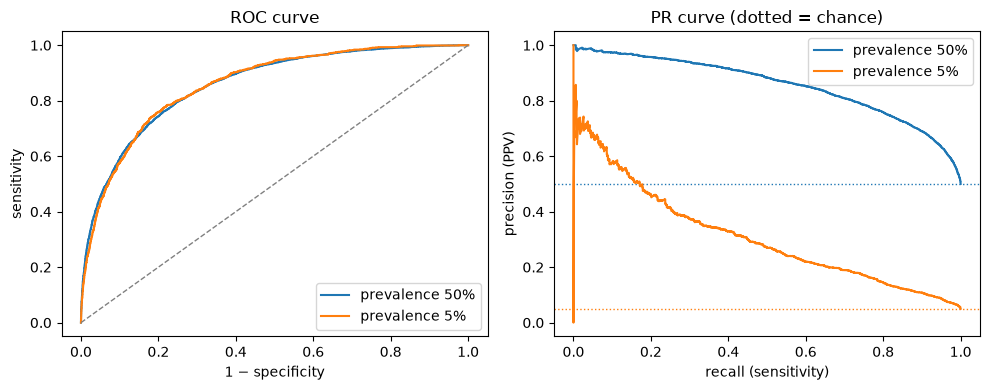

,prevalence,ROC-AUC,PR-AUC,PR-AUC chance level,sensitivity @0.75,specificity @0.75,PPV @0.75
0,0.50,0.857,0.856,0.50,0.776,0.770,0.771
1,0.05,0.858,0.309,0.05,0.785,0.774,0.154


In [6]:
def simulate(prevalence, n=20000):
    n_pos = int(n * prevalence)
    y_sim = np.r_[np.ones(n_pos), np.zeros(n - n_pos)].astype(int)
    s_sim = np.r_[rng.normal(1.5, 1, n_pos), rng.normal(0, 1, n - n_pos)]
    return y_sim, s_sim


rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rows = []
for prevalence in (0.5, 0.05):
    y_sim, s_sim = simulate(prevalence)
    fpr, tpr, _ = roc_curve(y_sim, s_sim)
    precision, recall, _ = precision_recall_curve(y_sim, s_sim)
    axes[0].plot(fpr, tpr, label=f"prevalence {prevalence:.0%}")
    axes[1].plot(recall, precision, label=f"prevalence {prevalence:.0%}")
    axes[1].axhline(prevalence, ls=":", lw=1, color=axes[1].lines[-1].get_color())
    pred = s_sim >= 0.75
    rows.append({"prevalence": prevalence, "ROC-AUC": roc_auc_score(y_sim, s_sim),
                 "PR-AUC": average_precision_score(y_sim, s_sim), "PR-AUC chance level": prevalence,
                 "sensitivity @0.75": pred[y_sim == 1].mean(), "specificity @0.75": 1 - pred[y_sim == 0].mean(),
                 "PPV @0.75": y_sim[pred].mean()})
axes[0].plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
axes[0].set(xlabel="1 − specificity", ylabel="sensitivity", title="ROC curve")
axes[1].set(xlabel="recall (sensitivity)", ylabel="precision (PPV)", title="PR curve (dotted = chance)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame(rows).round(3))

## Demo 3: AUC is a ranking probability
The share of (patient, control) pairs in which the patient scores higher, with ties counted as half, equals the ROC-AUC exactly.

In [7]:
y_small, s_small = simulate(0.5, n=400)
pos, neg = s_small[y_small == 1], s_small[y_small == 0]
pairwise = (pos[:, None] > neg[None, :]).mean() + 0.5 * (pos[:, None] == neg[None, :]).mean()
print(f"share of correctly ordered pairs = {pairwise:.4f}   ROC-AUC = {roc_auc_score(y_small, s_small):.4f}")

share of correctly ordered pairs = 0.8408   ROC-AUC = 0.8409


## Demo 4: why metrics are computed per fold instead of pooled
Fold 2's model ranks its participants exactly as well as fold 1's, but its scores sit on a shifted, stretched scale. Pooling the two folds' scores into one ROC mixes the scales and lowers the AUC.

In [8]:
y1, s1 = simulate(0.5, n=40)
y2, s2 = simulate(0.5, n=40)
s2 = 3 * s2 + 2                      # same ranking, different scale
print(f"fold 1 AUC {roc_auc_score(y1, s1):.3f} | fold 2 AUC {roc_auc_score(y2, s2):.3f} | "
      f"mean of folds {(roc_auc_score(y1, s1) + roc_auc_score(y2, s2)) / 2:.3f} | "
      f"pooled {roc_auc_score(np.r_[y1, y2], np.r_[s1, s2]):.3f}")

fold 1 AUC 0.847 | fold 2 AUC 0.857 | mean of folds 0.852 | pooled 0.748


## Demo 5: fold metrics, summaries and the paired ΔAUC with its corrected interval
This is a synthetic nested-CV run (3 repeats × 5 folds, small grids) in which both modalities carry signal.

In [9]:
X, y, blocks = make_synthetic(n=80, signal="both", effect=0.8, seed=3)
ids = np.array([f"sub-{i:02d}" for i in range(len(y))])
demo_seeds = [11, 23, 37]
cfg = demo_config()
predictions, selections, _ = run_nested_cv(
    X, y, ids, partial(build_models, cfg, blocks,
                       include=["structural", "functional", "early_fusion", "equal_weight", "mkl", "stacking"]),
    seeds=demo_seeds, n_outer=5, n_inner=3, n_jobs=2)
folds = fold_metrics(predictions)
display(summarize(folds).round(3))

diffs = paired_differences(folds, "mkl", "functional")
ci = corrected_resampled_ci(diffs, test_train_ratio=1 / (5 - 1))
naive_half_width = stats.t.ppf(0.975, len(diffs) - 1) * diffs.std(ddof=1) / np.sqrt(len(diffs))
print(f"mean ΔAUC (MKL − functional) = {ci['mean']:.3f} over {ci['n_folds']} folds")
print(f"naive 95% CI:     [{ci['mean'] - naive_half_width:.3f}, {ci['mean'] + naive_half_width:.3f}]   (too narrow)")
print(f"corrected 95% CI: [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")

,model,auc_mean,auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,prevalence_mean,prevalence_std
0,structural,0.819,0.077,0.853,0.064,0.729,0.081,0.717,0.110,0.742,0.197,0.5,0.0
1,functional,0.762,0.122,0.814,0.092,0.621,0.126,0.525,0.335,0.717,0.373,0.5,0.0
2,early_fusion,0.876,0.082,0.905,0.058,0.717,0.129,0.650,0.260,0.783,0.329,0.5,0.0
3,equal_weight,0.880,0.082,0.909,0.062,0.762,0.098,0.675,0.230,0.850,0.118,0.5,0.0
4,mkl,0.852,0.119,0.890,0.083,0.750,0.103,0.658,0.243,0.842,0.110,0.5,0.0
5,stacking,0.807,0.064,0.847,0.049,0.679,0.094,0.642,0.205,0.717,0.277,0.5,0.0


mean ΔAUC (MKL − functional) = 0.090 over 15 folds
naive 95% CI:     [0.040, 0.139]   (too narrow)
corrected 95% CI: [-0.018, 0.197]


## Demo 6: the two permutation nulls
We run a small number of permutations for illustration; the real analysis uses 1,000. Each permutation reruns the full nested pipeline.
- **Left, beats chance:** after label permutation, the null AUCs centre on 0.5, and the observed AUC lies far to the right.
- **Right, primary test:** after permuting the structural block, the null ΔAUC centres near 0, because MKL can then only fall back on functional connectivity.

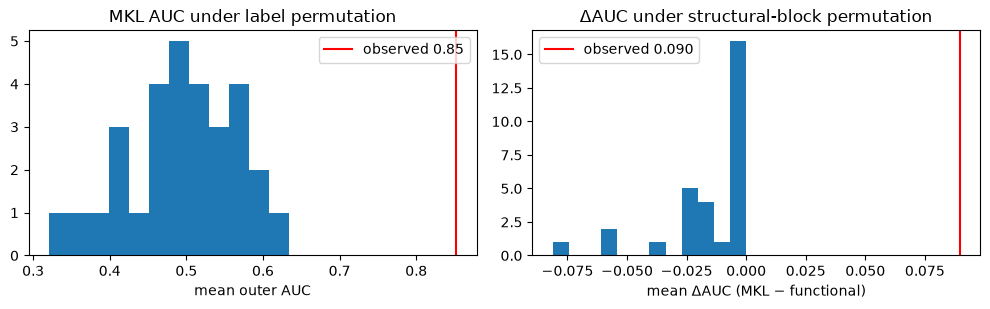

beats chance:  p = 0.032  (smallest possible with B=30: 0.032)
primary test:  p = 0.032


In [10]:
B = 30
label_null = run_permutations(X, y, ids, partial(build_models, cfg, blocks, include=["structural", "functional", "mkl"]),
                              demo_seeds, mean_auc_by_model, "labels", range(B), seed=20260912,
                              n_outer=5, n_inner=3, n_jobs=-1)
block_null = run_permutations(X, y, ids, partial(build_models, cfg, blocks, include=["mkl", "functional"]),
                              demo_seeds, partial(mean_paired_auc_difference, model_a="mkl", model_b="functional"),
                              "block", range(B), seed=20260912, block=blocks["structural"],
                              n_outer=5, n_inner=3, n_jobs=-1)

observed_auc = mean_auc_by_model(predictions)["mkl"]
observed_delta = mean_paired_auc_difference(predictions, "mkl", "functional")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(label_null["mkl"], bins=12)
axes[0].axvline(observed_auc, color="red", label=f"observed {observed_auc:.2f}")
axes[0].set(title="MKL AUC under label permutation", xlabel="mean outer AUC")
axes[1].hist(block_null["statistic"], bins=12)
axes[1].axvline(observed_delta, color="red", label=f"observed {observed_delta:.3f}")
axes[1].set(title="ΔAUC under structural-block permutation", xlabel="mean ΔAUC (MKL − functional)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()
print(f"beats chance:  p = {permutation_p_value(observed_auc, label_null['mkl']):.3f}  (smallest possible with B={B}: {1 / (B + 1):.3f})")
print(f"primary test:  p = {permutation_p_value(observed_delta, block_null['statistic']):.3f}")

## Demo 7: Holm correction and the decision rule

In [11]:
raw = {"early_fusion": 0.012, "equal_weight": 0.030, "stacking": 0.200, "structural": 0.004}
display(pd.DataFrame({"raw p": raw, "Holm-adjusted p": holm(raw)}).sort_values("raw p"))

examples = [(0.05, 0.01, 0.09, 0.01), (0.01, 0.002, 0.018, 0.01), (-0.01, -0.03, 0.01, 0.40), (0.02, -0.01, 0.05, 0.08)]
display(pd.DataFrame([{"mean ΔAUC": m, "CI low": lo, "CI high": hi, "p (block)": p,
                       "result": classify_primary_result(m, lo, hi, p, delta=0.02)} for m, lo, hi, p in examples]))

,raw p,Holm-adjusted p
structural,0.004,0.016
early_fusion,0.012,0.036
equal_weight,0.030,0.060
stacking,0.200,0.200


,mean ΔAUC,CI low,CI high,p (block),result
0,0.05,0.010,0.090,0.01,superiority supported
1,0.01,0.002,0.018,0.01,detectable but below the minimum meaningful di...
2,-0.01,-0.030,0.010,0.40,no meaningful incremental value
3,0.02,-0.010,0.050,0.08,inconclusive


## Run on the real data
Two steps:
1. **Permutation nulls.** Each chunk is saved separately in `results/permutation_tests/`, so chunks can be run over several sessions or machines and are combined automatically. At COBRE size, 1,000 permutations take roughly 30 min (structural block) and 1 h (labels) on 16 cores.
2. **`report_results()`.** Writes the fold metrics, summaries, paired comparisons (with Holm-adjusted p-values), `primary_result.json` and the beats-chance table.

In [12]:
USE_REAL_DATA = False
RUN_PERMUTATIONS = False     # set True to compute (a chunk of) the nulls in this session

if USE_REAL_DATA:
    if RUN_PERMUTATIONS:
        run_permutation_chunk("structural_block", start=0, n_permutations=1000)
        run_permutation_chunk("labels", start=0, n_permutations=1000)
    report = report_results()
    display(report["summary"].round(3), report["comparisons"].round(4))
    print(json.dumps(report["primary"], indent=2, default=float))
    if report["beats_chance"] is not None:
        display(report["beats_chance"])
else:
    print("Synthetic mode: set USE_REAL_DATA = True after running notebook 05 on the real data.")

Synthetic mode: set USE_REAL_DATA = True after running notebook 05 on the real data.
